In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in hbmnl_normal_experiments/ and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in hbmnl_normal_experiments/. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / BAYESM
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"folder        : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler_standard(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

folder        : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_normal_experiments
scenario=standard  K_MODEL=1  K_TRUE=1
samplers found: ['BAYESM', 'HMC', 'NUTS']


  BAYESM   mu (2, 10000, 1, 4)
  HMC      mu (2, 10000, 1, 4)
  NUTS     mu (2, 10000, 1, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' support (union over samplers); the
# True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_standard(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted support):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted support):
  Alt1       [-5.62, +4.09]
  Alt2       [-6.77, +5.73]
  Alt3       [-5.73, +7.26]
  Price      [-3.98, +5.37]


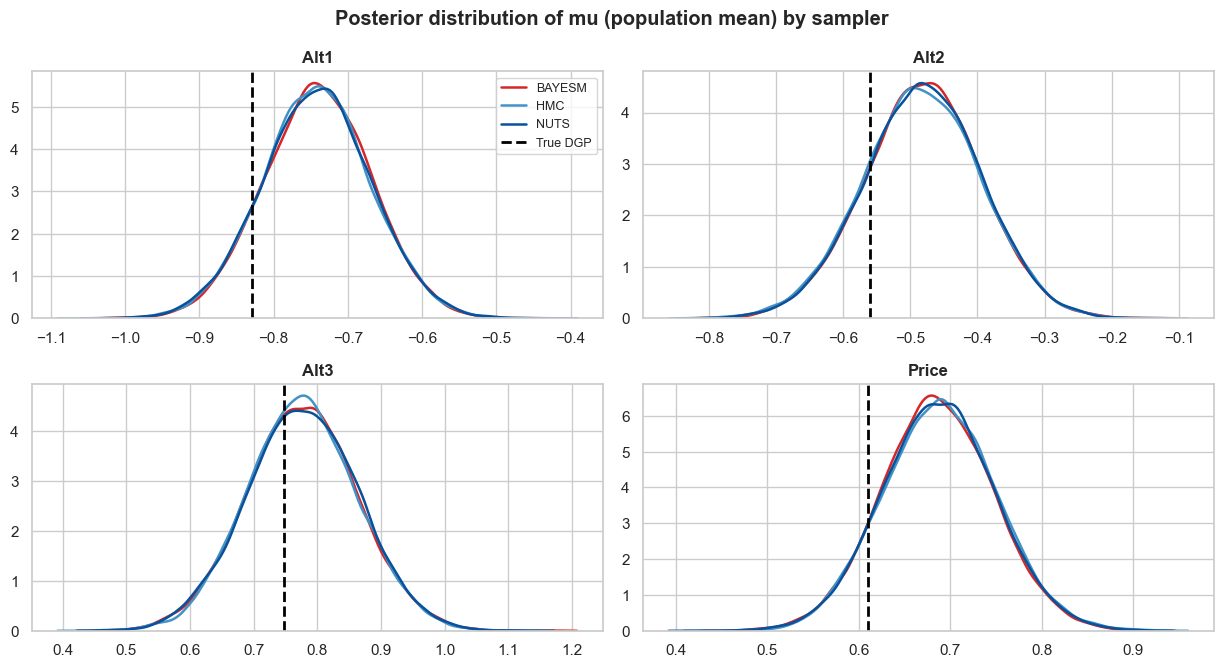

In [4]:
# ── Cell 4 : Posterior Distribution of mu, Across Samplers ──────────
# With one component there is no label-switching, so - unlike the mixture case -
# comparing samplers' posterior distributions of mu directly is meaningful, not
# just the derived density below.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "BAYESM": "#d62728"}

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for m in models:
        draws = np.asarray(m["mu"])[:, :, 0, j].reshape(-1)
        sns.kdeplot(draws, ax=ax[j], label=m["name"], color=colors.get(m["name"], "#7f7f7f"), lw=1.8)
    ax[j].axvline(true_model["mu"][0, 0, 0, j], color="black", ls="--", lw=2.0, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_ylabel("")
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Posterior distribution of mu (population mean) by sampler", fontweight="bold")
fig.tight_layout()
plt.show()

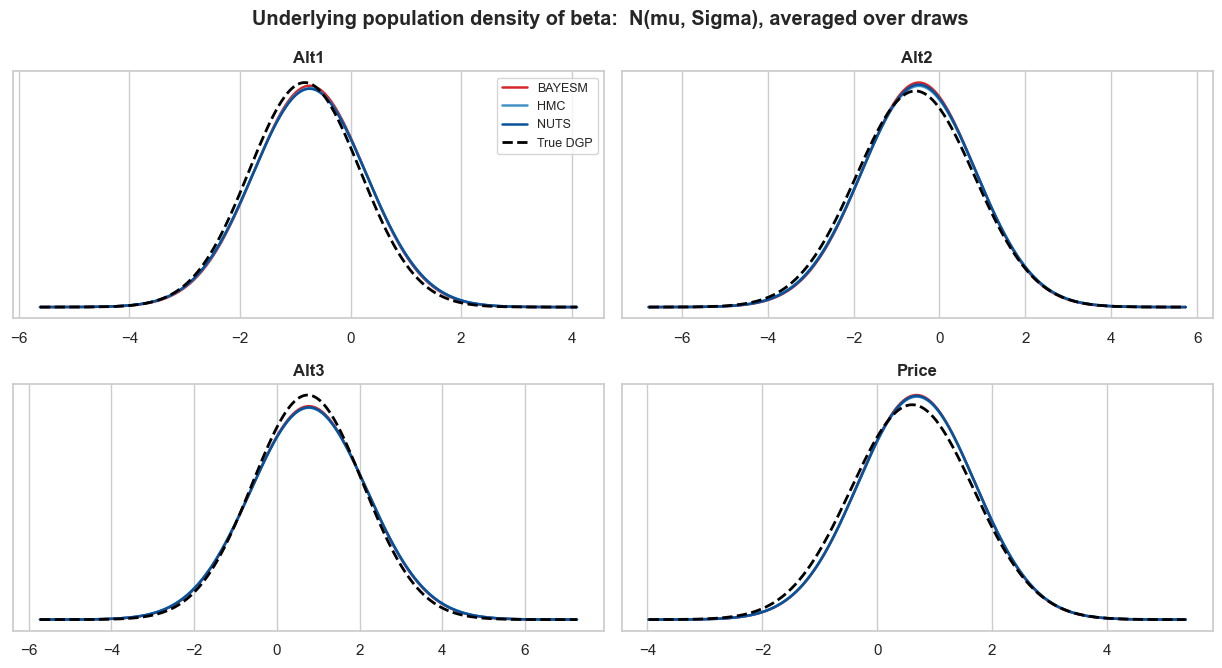

In [5]:
# ── Cell 5 : Underlying Population Density (Rossi Eq. 5.5.19, K=1) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "BAYESM": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Underlying population density of beta:  N(mu, Sigma), averaged over draws", fontweight="bold")
fig.tight_layout()
plt.show()

In [6]:
# ── Cell 6 : Density Distances vs True DGP ──────────
# Every sampler's density is compared ONLY to the True DGP density (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler param                                                    
BAYESM  Alt1     0.03237  0.00428  0.00105  0.03553       0.08843
        Alt2     0.02674  0.00279  0.00071  0.02778       0.08005
        Alt3     0.02819  0.00333  0.00079  0.02622       0.06298
        Price    0.03266  0.00413  0.00107  0.03355       0.07645
HMC     Alt1     0.03383  0.00472  0.00114  0.03577       0.08699
        Alt2     0.02208  0.00192  0.00049  0.02432       0.07670
        Alt3     0.03176  0.00425  0.00101  0.02968       0.07084
        Price    0.03141  0.00384  0.00099  0.03299       0.07880
NUTS    Alt1     0.03444  0.00491  0.00118  0.03622       0.08748
        Alt2     0.02413  0.00228  0.00058  0.02587       0.07927
        Alt3     0.03088  0.00401  0.00095  0.02884       0.06908
        Price    0.03189  0.00395  0.00102  0.03315       0.07749

In [7]:
# ── Cell 7 : Posterior Mean of mu and Sigma (Rossi Eq. 5.5.2, K=1) ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[beta]  (posterior mean of mu, averaged over draws):")
display(mean_tbl.round(3))
print("diag Var[beta]  (posterior mean of Sigma's diagonal, averaged over draws):")
display(var_tbl.round(3))

E[beta]  (posterior mean of mu, averaged over draws):


,BAYESM,HMC,NUTS,True DGP
Alt1,-0.741,-0.742,-0.742,-0.829
Alt2,-0.481,-0.483,-0.481,-0.560
Alt3,0.776,0.776,0.777,0.747
Price,0.686,0.689,0.688,0.610


diag Var[beta]  (posterior mean of Sigma's diagonal, averaged over draws):


,BAYESM,HMC,NUTS,True DGP
Alt1,1.046,1.071,1.076,1.011
Alt2,1.764,1.819,1.797,1.896
Alt3,1.986,2.016,2.008,1.788
Price,1.050,1.065,1.058,1.143


In [8]:
# ── Cell 8 : Convergence - Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the per-draw density
# N(x; mu, Sigma), over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- BAYESM ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,26,4069.691,5437.534,1.001,1.0
Alt2,26,5155.219,7262.140,1.000,1.0
Alt3,26,6477.568,9235.533,1.000,1.0
Price,26,7468.016,10408.810,1.000,1.0


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,26,894.306,1889.039,1.001,1.001
Alt2,26,191.336,560.907,1.010,1.006
Alt3,26,482.019,859.235,1.010,1.005
Price,26,518.560,842.125,1.004,1.002


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,26,8346.430,9765.688,1.001,1.0
Alt2,26,10673.207,12748.034,1.000,1.0
Alt3,26,14336.758,15593.059,1.000,1.0
Price,26,15911.779,18081.071,1.000,1.0


In [9]:
# ── Cell 9 : Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - With one component there is no label-switching, so mu's raw posterior")
print("   (Cell 4) is already directly comparable across samplers - the density/moment")
print("   machinery below (shared with the mixture notebook - K=1 here) is an extra")
print("   cross-check, not a requirement the way it is for the mixture model.")
print(" - The grid is anchored to the fitted models' support; the True DGP is an")
print("   overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- BAYESM ---


ESS    Rhat
param moment                    
Alt1  Mean     6365.9243  1.0005
      Var      4356.0047  1.0002
Alt2  Mean     9183.6076  1.0001
      Var      5376.4194  1.0004
Alt3  Mean    13157.7184  1.0000
      Var      6548.1174  1.0001
Price Mean    13794.1166  1.0001
      Var      7658.5269  1.0002

--- HMC ---


ESS    Rhat
param moment                   
Alt1  Mean    4113.3407  1.0004
      Var      902.6303  1.0012
Alt2  Mean    1648.9787  1.0011
      Var      190.5152  1.0097
Alt3  Mean    1563.2597  1.0021
      Var      493.0460  1.0082
Price Mean    1287.0485  1.0016
      Var      518.2939  1.0021

--- NUTS ---


ESS    Rhat
param moment                    
Alt1  Mean    11782.4458  0.9999
      Var      8514.2826  1.0006
Alt2  Mean    13246.7152  1.0001
      Var     11491.0522  1.0001
Alt3  Mean    15406.7429  1.0001
      Var     16066.9209  1.0000
Price Mean    16598.6666  1.0000
      Var     19261.0717  1.0000


Notes:
 - With one component there is no label-switching, so mu's raw posterior
   (Cell 4) is already directly comparable across samplers - the density/moment
   machinery below (shared with the mixture notebook - K=1 here) is an extra
   cross-check, not a requirement the way it is for the mixture model.
 - The grid is anchored to the fitted models' support; the True DGP is an
   overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
